In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
cohort_data = pd.read_csv("cohort_retention.csv")

print(cohort_data.shape)

cohort_data.head()

(25, 20)


,CohortMonth,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20
0,2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.004386,NaN,NaN,NaN,NaN,NaN,NaN,0.004386,NaN,NaN,NaN,NaN,0.004386
2,2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01,1.0,NaN,0.001855,0.001855,0.003711,NaN,0.001855,0.001855,0.001855,NaN,NaN,NaN,0.003711,0.001855,NaN,NaN,0.001855,0.005566,NaN
4,2017-02,1.0,0.002406,0.001604,0.000802,0.004812,NaN,0.002406,0.000802,0.001604,0.002406,0.001604,0.002406,0.001604,0.001604,0.001604,NaN,0.000802,0.001604,NaN


In [10]:
cohort_data.columns

Index(['CohortMonth', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '20'],
      dtype='object')

In [11]:
retention_matrix = cohort_data.set_index("CohortMonth")

retention_matrix.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20
CohortMonth,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.004386,NaN,NaN,NaN,NaN,NaN,NaN,0.004386,NaN,NaN,NaN,NaN,0.004386
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,NaN,0.001855,0.001855,0.003711,NaN,0.001855,0.001855,0.001855,NaN,NaN,NaN,0.003711,0.001855,NaN,NaN,0.001855,0.005566,NaN
2017-02,1.0,0.002406,0.001604,0.000802,0.004812,NaN,0.002406,0.000802,0.001604,0.002406,0.001604,0.002406,0.001604,0.001604,0.001604,NaN,0.000802,0.001604,NaN


In [13]:
retention_matrix = cohort_data.set_index("CohortMonth")

retention_matrix = retention_matrix * 100

retention_matrix.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20
CohortMonth,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.438596,NaN,NaN,NaN,NaN,NaN,NaN,0.438596,NaN,NaN,NaN,NaN,0.438596
2016-12,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,NaN,0.185529,0.185529,0.371058,NaN,0.185529,0.185529,0.185529,NaN,NaN,NaN,0.371058,0.185529,NaN,NaN,0.185529,0.556586,NaN
2017-02,100.0,0.240577,0.160385,0.080192,0.481155,NaN,0.240577,0.080192,0.160385,0.240577,0.160385,0.240577,0.160385,0.160385,0.160385,NaN,0.080192,0.160385,NaN


# Cohort Retention Heatmap

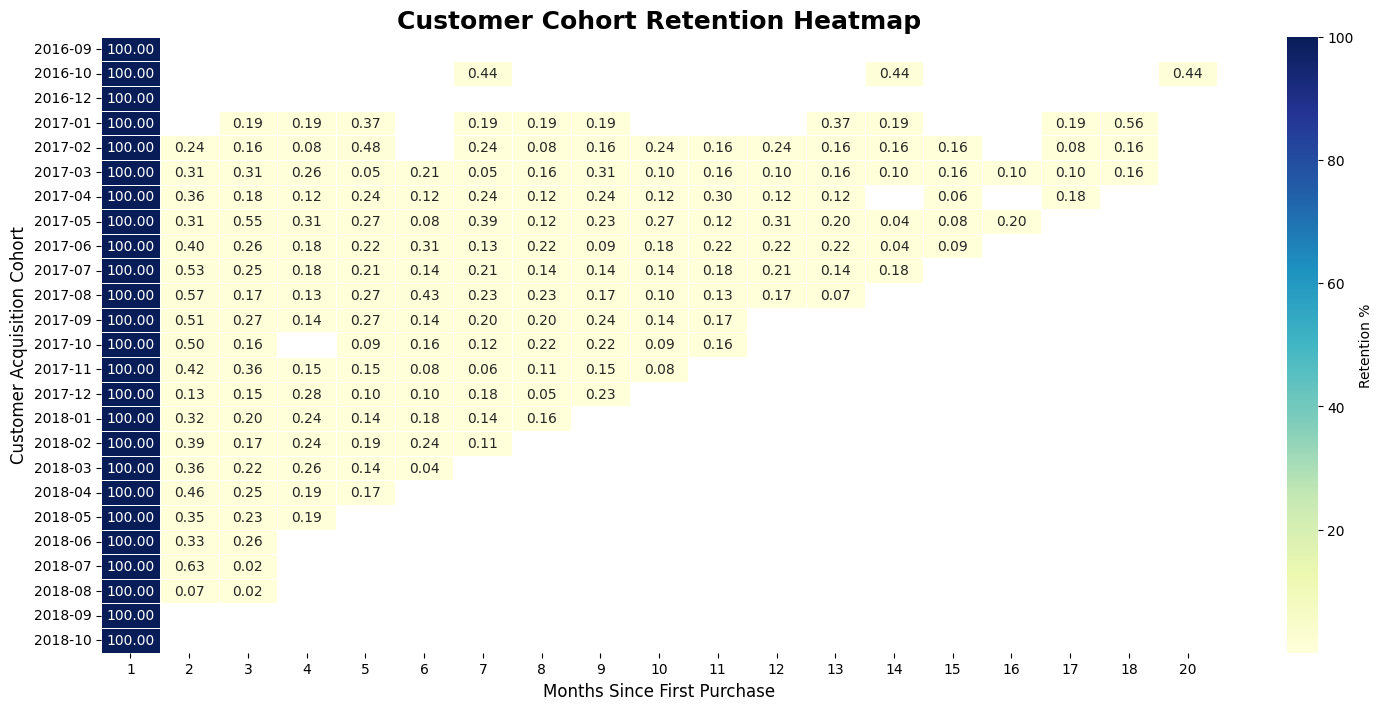

In [14]:
plt.figure(figsize=(18,8))

sns.heatmap(

    retention_matrix,

    annot=True,

    fmt=".2f",

    cmap="YlGnBu",

    linewidths=0.5,

    linecolor="white",

    cbar_kws={'label':'Retention %'}

)

plt.title(

    "Customer Cohort Retention Heatmap",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(

    "Months Since First Purchase",

    fontsize=12

)

plt.ylabel(

    "Customer Acquisition Cohort",

    fontsize=12

)

plt.xticks(rotation=0)

plt.yticks(rotation=0)

plt.show()

# Retention Decay Curve

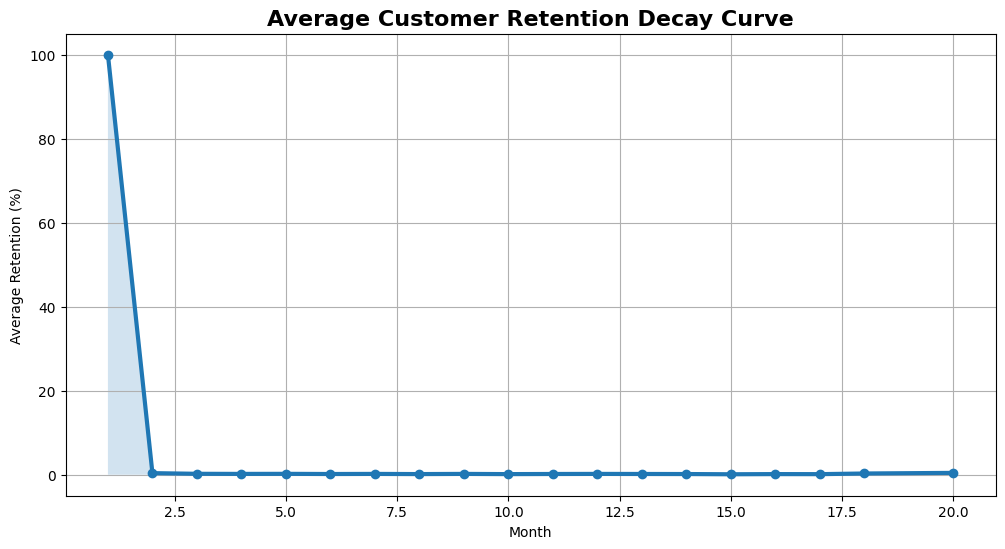

In [15]:
average_retention = retention_matrix.mean()

plt.figure(figsize=(12,6))

plt.plot(

    average_retention.index.astype(int),

    average_retention.values,

    marker='o',

    linewidth=3

)

plt.fill_between(

    average_retention.index.astype(int),

    average_retention.values,

    alpha=0.2

)

plt.title(

    "Average Customer Retention Decay Curve",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Month")

plt.ylabel("Average Retention (%)")

plt.grid(True)

plt.show()

# Cohort Performance Summary

In [16]:
cohort_summary = pd.DataFrame({

    "Average_Retention":retention_matrix.mean(axis=1),

    "Highest_Retention":retention_matrix.max(axis=1),

    "Lowest_Retention":retention_matrix.min(axis=1),

    "Std_Deviation":retention_matrix.std(axis=1)

})

cohort_summary

,Average_Retention,Highest_Retention,Lowest_Retention,Std_Deviation
CohortMonth,,,,
2016-09,100.000000,100.0,100.000000,NaN
2016-10,25.328947,100.0,0.438596,49.780702
2016-12,100.000000,100.0,100.000000,NaN
2017-01,9.327037,100.0,0.185529,30.073072
2017-02,6.425421,100.0,0.080192,24.953404
2017-03,5.712377,100.0,0.052274,23.531240
2017-04,6.832740,100.0,0.059312,25.774073
2017-05,6.467285,100.0,0.039062,24.942406
2017-06,6.851607,100.0,0.044033,25.768881


# Best & Worst Cohorts

In [17]:
best_cohort = cohort_summary['Average_Retention'].idxmax()

worst_cohort = cohort_summary['Average_Retention'].idxmin()

print("Best Performing Cohort :",best_cohort)

print("Worst Performing Cohort :",worst_cohort)

Best Performing Cohort : 2016-09
Worst Performing Cohort : 2017-03


# Retention Risk Score

In [18]:
cohort_summary['Retention_Risk_Score'] = (

    100

    -

    cohort_summary['Average_Retention']

)

cohort_summary

,Average_Retention,Highest_Retention,Lowest_Retention,Std_Deviation,Retention_Risk_Score
CohortMonth,,,,,
2016-09,100.000000,100.0,100.000000,NaN,0.000000
2016-10,25.328947,100.0,0.438596,49.780702,74.671053
2016-12,100.000000,100.0,100.000000,NaN,0.000000
2017-01,9.327037,100.0,0.185529,30.073072,90.672963
2017-02,6.425421,100.0,0.080192,24.953404,93.574579
2017-03,5.712377,100.0,0.052274,23.531240,94.287623
2017-04,6.832740,100.0,0.059312,25.774073,93.167260
2017-05,6.467285,100.0,0.039062,24.942406,93.532715
2017-06,6.851607,100.0,0.044033,25.768881,93.148393


# Cohort Growth Classification

In [19]:
def classify(retention):

    if retention>=80:

        return "Excellent"

    elif retention>=60:

        return "Good"

    elif retention>=40:

        return "Average"

    else:

        return "Poor"

cohort_summary['Growth_Index'] = (

    cohort_summary['Average_Retention']

    .apply(classify)

)

cohort_summary.head()

,Average_Retention,Highest_Retention,Lowest_Retention,Std_Deviation,Retention_Risk_Score,Growth_Index
CohortMonth,,,,,,
2016-09,100.000000,100.0,100.000000,NaN,0.000000,Excellent
2016-10,25.328947,100.0,0.438596,49.780702,74.671053,Poor
2016-12,100.000000,100.0,100.000000,NaN,0.000000,Excellent
2017-01,9.327037,100.0,0.185529,30.073072,90.672963,Poor
2017-02,6.425421,100.0,0.080192,24.953404,93.574579,Poor


# Revenue Loss Due To Churn

In [20]:
estimated_total_revenue = 1000000

cohort_summary['Estimated_Revenue_Loss'] = (

    estimated_total_revenue

    *

    (

        100

        -

        cohort_summary['Average_Retention']

    )

    /

    100

)

cohort_summary.head()

,Average_Retention,Highest_Retention,Lowest_Retention,Std_Deviation,Retention_Risk_Score,Growth_Index,Estimated_Revenue_Loss
CohortMonth,,,,,,,
2016-09,100.000000,100.0,100.000000,NaN,0.000000,Excellent,0.000000
2016-10,25.328947,100.0,0.438596,49.780702,74.671053,Poor,746710.526316
2016-12,100.000000,100.0,100.000000,NaN,0.000000,Excellent,0.000000
2017-01,9.327037,100.0,0.185529,30.073072,90.672963,Poor,906729.634002
2017-02,6.425421,100.0,0.080192,24.953404,93.574579,Poor,935745.789896


# Revenue Recovery Opportunity

In [21]:
cohort_summary['Recovery_Potential'] = (

    cohort_summary['Estimated_Revenue_Loss']

    *0.30

)

cohort_summary.head()

,Average_Retention,Highest_Retention,Lowest_Retention,Std_Deviation,Retention_Risk_Score,Growth_Index,Estimated_Revenue_Loss,Recovery_Potential
CohortMonth,,,,,,,,
2016-09,100.000000,100.0,100.000000,NaN,0.000000,Excellent,0.000000,0.000000
2016-10,25.328947,100.0,0.438596,49.780702,74.671053,Poor,746710.526316,224013.157895
2016-12,100.000000,100.0,100.000000,NaN,0.000000,Excellent,0.000000,0.000000
2017-01,9.327037,100.0,0.185529,30.073072,90.672963,Poor,906729.634002,272018.890201
2017-02,6.425421,100.0,0.080192,24.953404,93.574579,Poor,935745.789896,280723.736969


# Customer Survival Analysis

In [22]:
customer_survival = pd.DataFrame({

    "Month":average_retention.index,

    "Survival_Rate":average_retention.values

})

customer_survival

,Month,Survival_Rate
0,1,100.000000
1,2,0.377736
2,3,0.218940
3,4,0.195284
4,5,0.210903
5,6,0.170218
6,7,0.195544
7,8,0.153703
8,9,0.197056
9,10,0.146071


# Retention Opportunity Score

In [23]:
cohort_summary['Opportunity_Score'] = (

    100

    -

    cohort_summary['Average_Retention']

)

cohort_summary

,Average_Retention,Highest_Retention,Lowest_Retention,Std_Deviation,Retention_Risk_Score,Growth_Index,Estimated_Revenue_Loss,Recovery_Potential,Opportunity_Score
CohortMonth,,,,,,,,,
2016-09,100.000000,100.0,100.000000,NaN,0.000000,Excellent,0.000000,0.000000,0.000000
2016-10,25.328947,100.0,0.438596,49.780702,74.671053,Poor,746710.526316,224013.157895,74.671053
2016-12,100.000000,100.0,100.000000,NaN,0.000000,Excellent,0.000000,0.000000,0.000000
2017-01,9.327037,100.0,0.185529,30.073072,90.672963,Poor,906729.634002,272018.890201,90.672963
2017-02,6.425421,100.0,0.080192,24.953404,93.574579,Poor,935745.789896,280723.736969,93.574579
2017-03,5.712377,100.0,0.052274,23.531240,94.287623,Poor,942876.226985,282862.868095,94.287623
2017-04,6.832740,100.0,0.059312,25.774073,93.167260,Poor,931672.597865,279501.779359,93.167260
2017-05,6.467285,100.0,0.039062,24.942406,93.532715,Poor,935327.148438,280598.144531,93.532715
2017-06,6.851607,100.0,0.044033,25.768881,93.148393,Poor,931483.927785,279445.178336,93.148393


# AI Retention Advisor

In [24]:
print("="*70)

print("AI RETENTION ADVISOR")

print("="*70)

print()

print("Best Cohort :",best_cohort)

print("Worst Cohort :",worst_cohort)

print()

print("Recommendations")

print("--------------------------")

print("1. Strengthen customer engagement after Month 2.")

print("2. Launch personalised loyalty campaigns.")

print("3. Improve onboarding experience.")

print("4. Target weaker cohorts with retention offers.")

print("5. Reward repeat customers.")

print("6. Continuously monitor customer retention trends.")

AI RETENTION ADVISOR

Best Cohort : 2016-09
Worst Cohort : 2017-03

Recommendations
--------------------------
1. Strengthen customer engagement after Month 2.
2. Launch personalised loyalty campaigns.
3. Improve onboarding experience.
4. Target weaker cohorts with retention offers.
5. Reward repeat customers.
6. Continuously monitor customer retention trends.


# Executive Dashboard Dataset

In [25]:
executive_dashboard = pd.DataFrame({

    "Metric":[

        "Best Cohort",

        "Worst Cohort",

        "Average Retention",

        "Highest Retention",

        "Lowest Retention",

        "Average Risk Score"

    ],

    "Value":[

        best_cohort,

        worst_cohort,

        round(average_retention.mean(),2),

        round(retention_matrix.max().max(),2),

        round(retention_matrix.min().min(),2),

        round(cohort_summary['Retention_Risk_Score'].mean(),2)

    ]

})

executive_dashboard

,Metric,Value
0,Best Cohort,2016-09
1,Worst Cohort,2017-03
2,Average Retention,5.46
3,Highest Retention,100.0
4,Lowest Retention,0.02
5,Average Risk Score,71.48


# Retention KPI Summary

In [26]:
retention_kpi = pd.DataFrame({

    "KPI":[

        "Number of Cohorts",

        "Average Retention",

        "Best Cohort",

        "Worst Cohort",

        "Average Risk Score"

    ],

    "Value":[

        len(retention_matrix),

        round(average_retention.mean(),2),

        best_cohort,

        worst_cohort,

        round(

            cohort_summary['Retention_Risk_Score'].mean(),

            2

        )

    ]

})

retention_kpi

,KPI,Value
0,Number of Cohorts,25
1,Average Retention,5.46
2,Best Cohort,2016-09
3,Worst Cohort,2017-03
4,Average Risk Score,71.48


In [27]:
cohort_summary.to_csv(

    "cohort_performance_summary.csv"

)

customer_survival.to_csv(

    "customer_survival.csv",

    index=False

)

executive_dashboard.to_csv(

    "retention_dashboard.csv",

    index=False

)

retention_kpi.to_csv(

    "retention_kpi.csv",

    index=False

)

print(

    "All Retention Files Exported Successfully"

)

All Retention Files Exported Successfully


In [28]:
print("="*70)

print("EXECUTIVE RETENTION SUMMARY")

print("="*70)

print()

print(f"Total Cohorts Analysed : {len(retention_matrix)}")

print(f"Best Cohort : {best_cohort}")

print(f"Worst Cohort : {worst_cohort}")

print(f"Average Retention : {round(average_retention.mean(),2)} %")

print(f"Average Risk Score : {round(cohort_summary['Retention_Risk_Score'].mean(),2)}")

print()

print("Business Recommendation")

print("--------------------------")

print("Prioritise retention campaigns for low-performing cohorts while reinforcing loyalty programmes for high-performing cohorts.")

EXECUTIVE RETENTION SUMMARY

Total Cohorts Analysed : 25
Best Cohort : 2016-09
Worst Cohort : 2017-03
Average Retention : 5.46 %
Average Risk Score : 71.48

Business Recommendation
--------------------------
Prioritise retention campaigns for low-performing cohorts while reinforcing loyalty programmes for high-performing cohorts.


# Retention Distribution Histogram

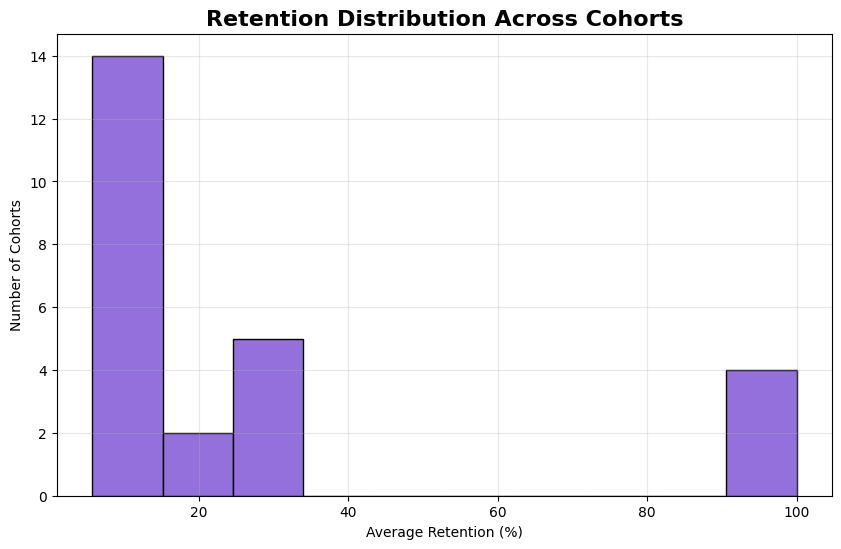

In [29]:
plt.figure(figsize=(10,6))

plt.hist(

    cohort_summary['Average_Retention'],

    bins=10,

    edgecolor='black',

    color='mediumpurple'

)

plt.title(
    'Retention Distribution Across Cohorts',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Average Retention (%)')

plt.ylabel('Number of Cohorts')

plt.grid(alpha=0.3)

plt.show()

# Cohort Size Trend

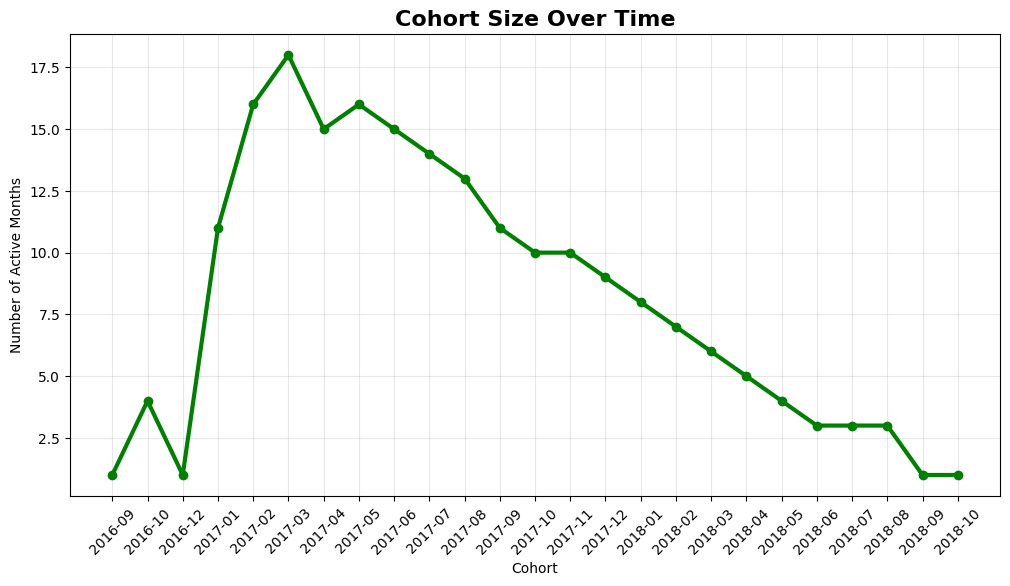

In [30]:
cohort_size = retention_matrix.notna().sum(axis=1)

plt.figure(figsize=(12,6))

plt.plot(

    cohort_size.index,

    cohort_size.values,

    marker='o',

    linewidth=3,

    color='green'

)

plt.title(
    'Cohort Size Over Time',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Cohort')

plt.ylabel('Number of Active Months')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

# Revenue Loss vs Revenue Retained

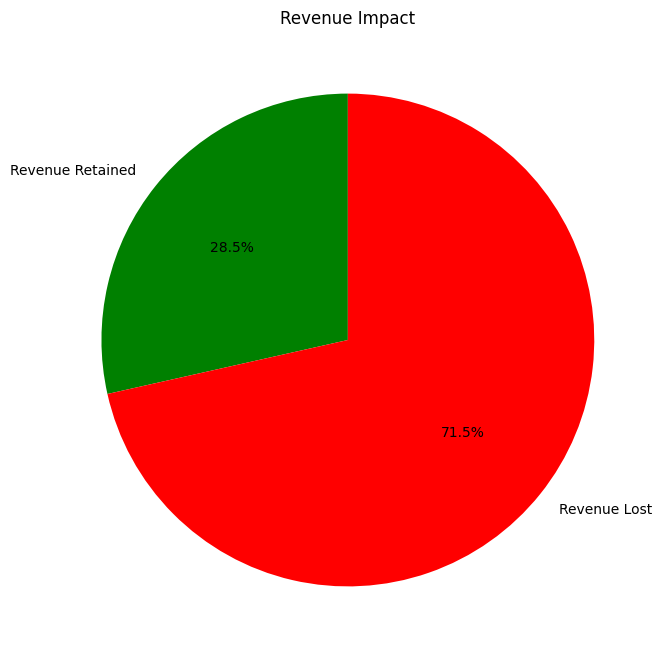

In [31]:
revenue_retained = estimated_total_revenue - cohort_summary['Estimated_Revenue_Loss'].mean()

plt.figure(figsize=(8,8))

plt.pie(

    [

        revenue_retained,

        cohort_summary['Estimated_Revenue_Loss'].mean()

    ],

    labels=[

        'Revenue Retained',

        'Revenue Lost'

    ],

    autopct='%1.1f%%',

    startangle=90,

    colors=['green','red']

)

plt.title('Revenue Impact')

plt.show()

# Retention Opportunity Score

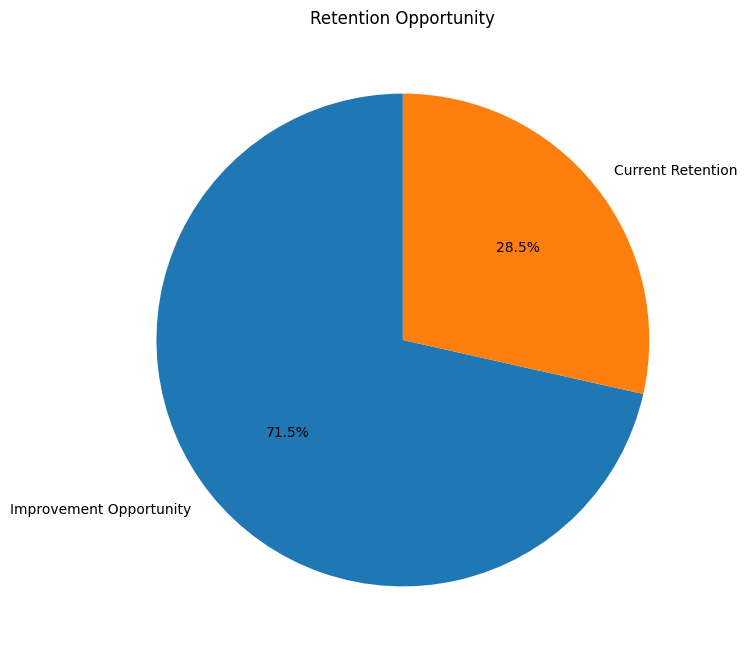

In [32]:
plt.figure(figsize=(8,8))

plt.pie(

    [

        cohort_summary['Opportunity_Score'].mean(),

        100-cohort_summary['Opportunity_Score'].mean()

    ],

    labels=[

        'Improvement Opportunity',

        'Current Retention'

    ],

    autopct='%1.1f%%',

    startangle=90

)

plt.title("Retention Opportunity")

plt.show()

# Cohort Growth Classification

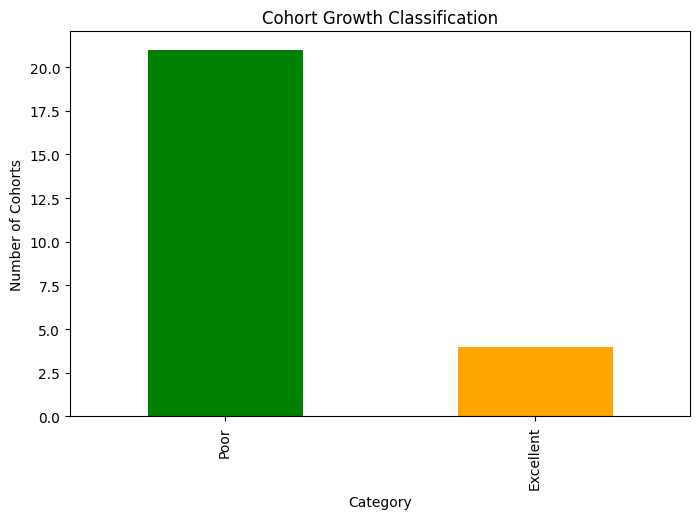

In [33]:
cohort_summary['Growth_Index'].value_counts().plot(

    kind='bar',

    figsize=(8,5),

    color=['green','orange','gold','red']

)

plt.title('Cohort Growth Classification')

plt.xlabel('Category')

plt.ylabel('Number of Cohorts')

plt.show()

# Customer Survival Curve

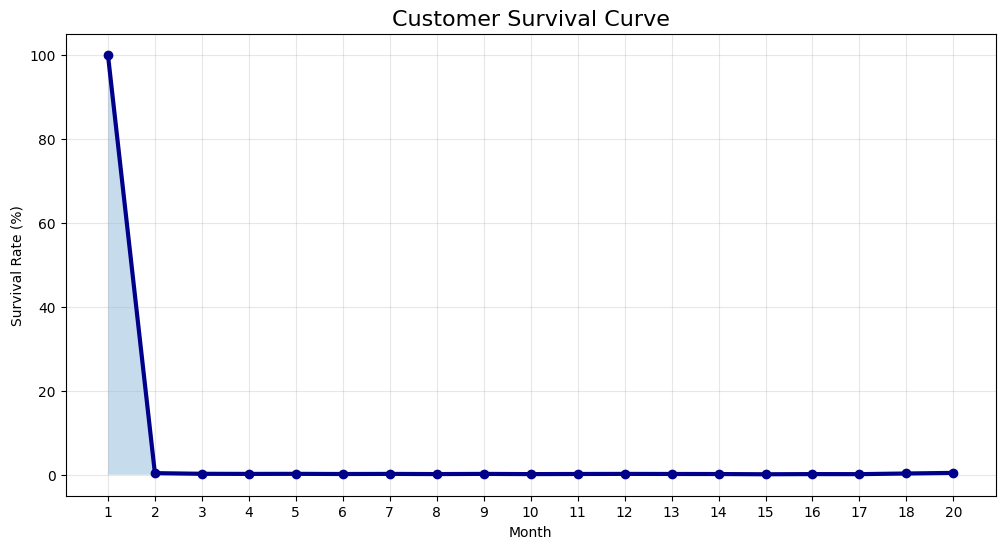

In [34]:
plt.figure(figsize=(12,6))

plt.plot(

    customer_survival['Month'],

    customer_survival['Survival_Rate'],

    marker='o',

    linewidth=3,

    color='darkblue'

)

plt.fill_between(

    customer_survival['Month'],

    customer_survival['Survival_Rate'],

    alpha=0.25

)

plt.title(

    'Customer Survival Curve',

    fontsize=16

)

plt.xlabel('Month')

plt.ylabel('Survival Rate (%)')

plt.grid(alpha=0.3)

plt.show()

# Retention Funnel

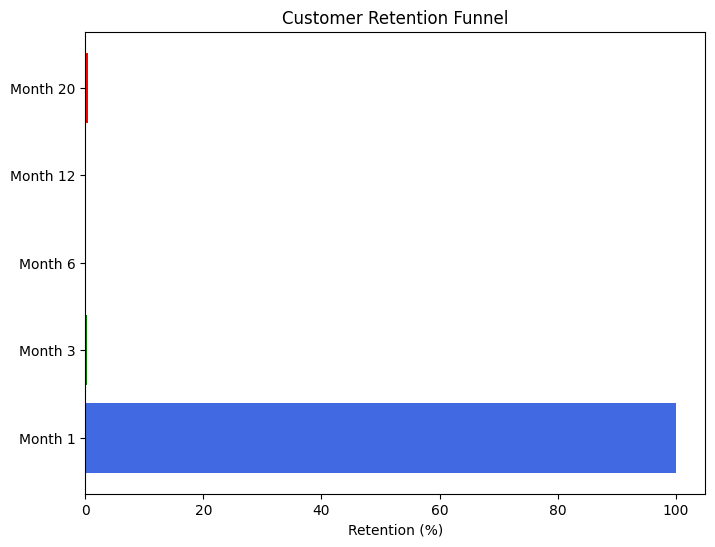

In [35]:
months=[

    'Month 1',

    'Month 3',

    'Month 6',

    'Month 12',

    'Month 20'

]

values=[

    retention_matrix.iloc[:,0].mean(),

    retention_matrix.iloc[:,2].mean(),

    retention_matrix.iloc[:,5].mean(),

    retention_matrix.iloc[:,11].mean(),

    retention_matrix.iloc[:,-1].mean()

]

plt.figure(figsize=(8,6))

plt.barh(

    months,

    values,

    color=['royalblue','green','gold','orange','red']

)

plt.title('Customer Retention Funnel')

plt.xlabel('Retention (%)')

plt.show()

# Best vs Worst Cohort Comparison

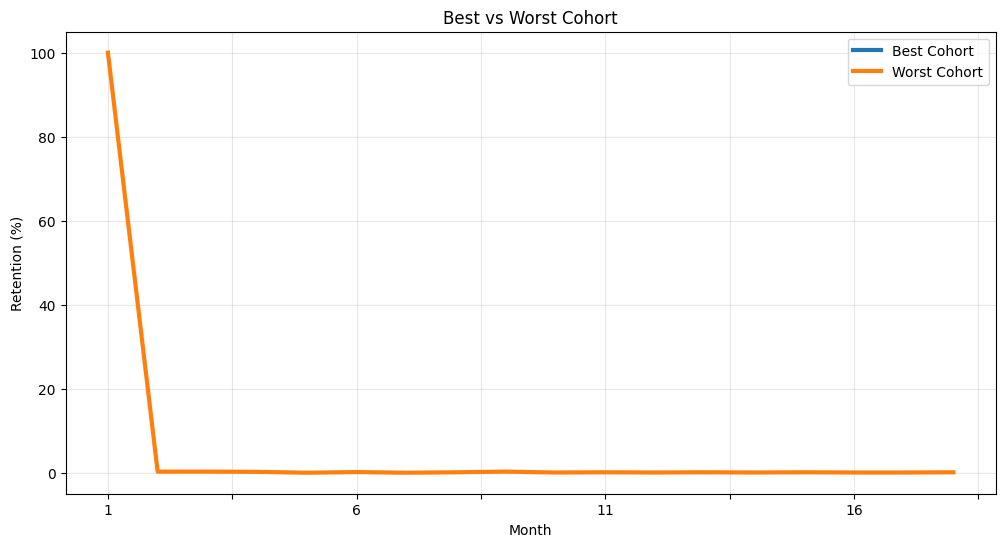

In [36]:
comparison = pd.DataFrame({

    'Best Cohort':

        retention_matrix.loc[best_cohort],

    'Worst Cohort':

        retention_matrix.loc[worst_cohort]

})

comparison.plot(

    figsize=(12,6),

    linewidth=3

)

plt.title(

    'Best vs Worst Cohort'

)

plt.xlabel('Month')

plt.ylabel('Retention (%)')

plt.grid(alpha=0.3)

plt.show()

# Average Monthly Retention

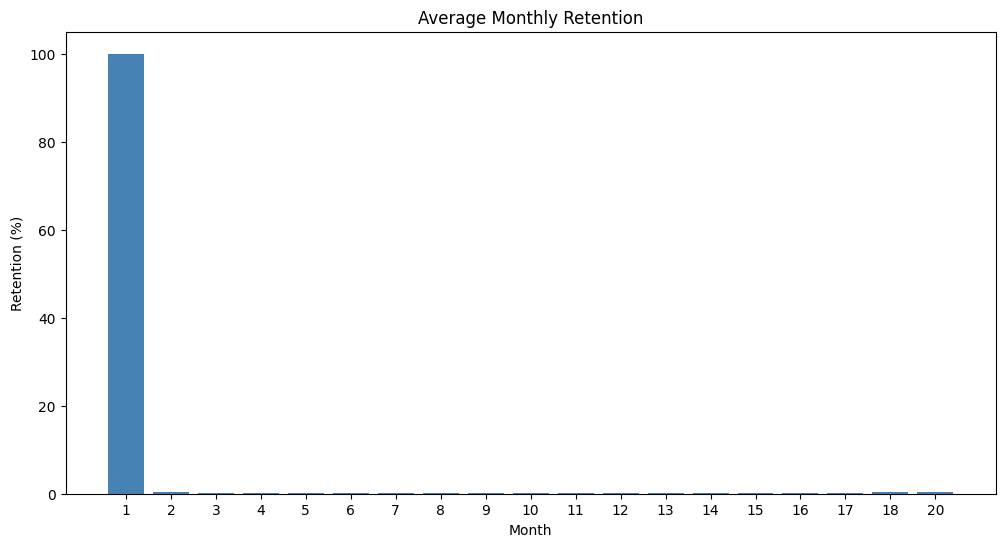

In [37]:
monthly_retention = retention_matrix.mean()

plt.figure(figsize=(12,6))

plt.bar(

    monthly_retention.index.astype(str),

    monthly_retention.values,

    color='steelblue'

)

plt.title(

    'Average Monthly Retention'

)

plt.xlabel('Month')

plt.ylabel('Retention (%)')

plt.show()

# Retention Trend with Moving Average

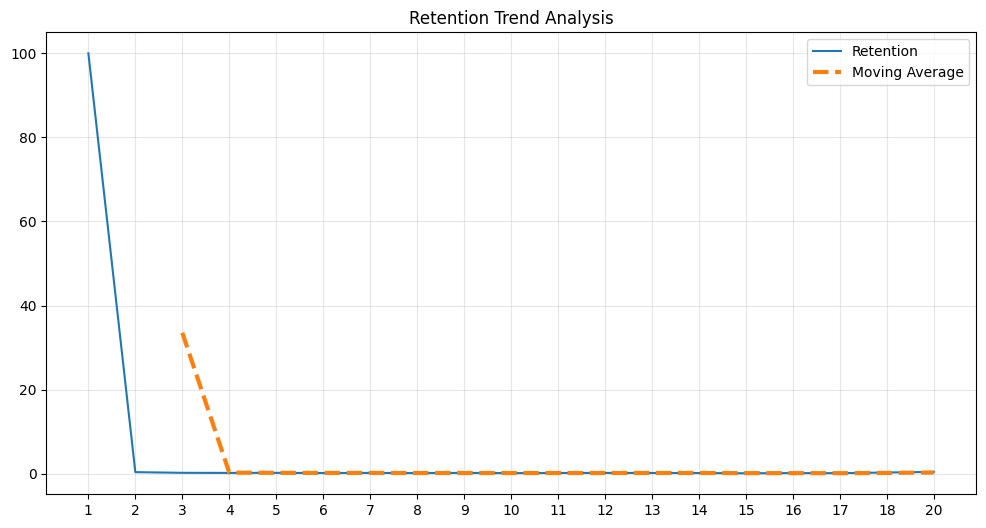

In [38]:
trend = average_retention

moving = trend.rolling(3).mean()

plt.figure(figsize=(12,6))

plt.plot(

    trend.index,

    trend.values,

    label='Retention'

)

plt.plot(

    moving.index,

    moving.values,

    linestyle='--',

    linewidth=3,

    label='Moving Average'

)

plt.legend()

plt.grid(alpha=0.3)

plt.title(

    'Retention Trend Analysis'

)

plt.show()

# Retention Prediction Model

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare data
X = np.array(average_retention.index.astype(int)).reshape(-1,1)
y = average_retention.values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predictions
predictions = model.predict(X)

# Metrics
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print("Model Performance")
print("----------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Performance
----------------------
MAE  : 11.5847
RMSE : 20.5835
R²   : 0.1468


# Actual vs Predicted Retention

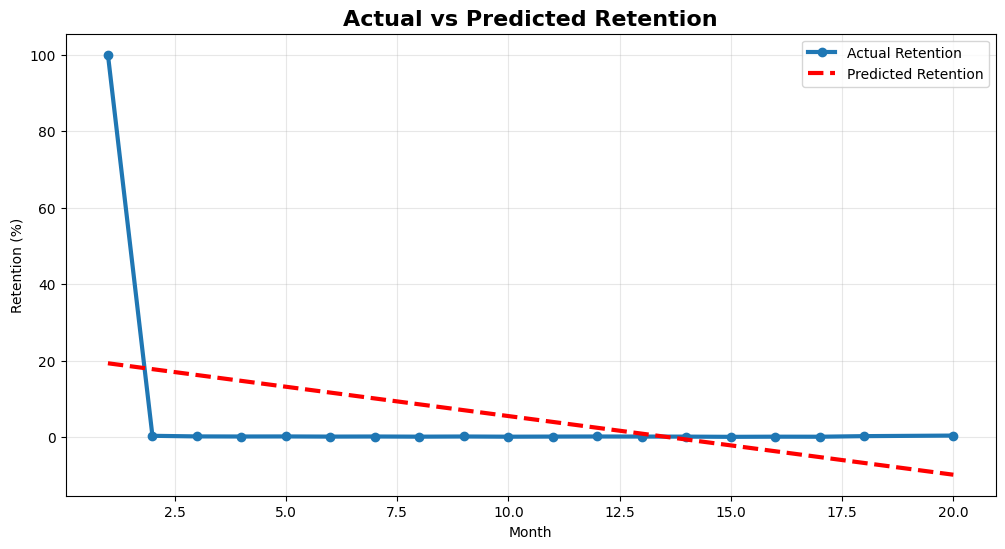

In [40]:
plt.figure(figsize=(12,6))

plt.plot(
    X.flatten(),
    y,
    marker='o',
    linewidth=3,
    label='Actual Retention'
)

plt.plot(
    X.flatten(),
    predictions,
    linestyle='--',
    linewidth=3,
    color='red',
    label='Predicted Retention'
)

plt.title(
    "Actual vs Predicted Retention",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Retention (%)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Forecast Next 12 Months

In [41]:
future_months = np.arange(
    X.max()+1,
    X.max()+13
).reshape(-1,1)

future_predictions = model.predict(future_months)

forecast = pd.DataFrame({

    "Month":future_months.flatten(),

    "Forecast_Retention":future_predictions

})

forecast

,Month,Forecast_Retention
0,21,-11.329123
1,22,-12.862587
2,23,-14.396051
3,24,-15.929515
4,25,-17.462979
5,26,-18.996442
6,27,-20.529906
7,28,-22.063370
8,29,-23.596834
9,30,-25.130298


# Forecast Graph

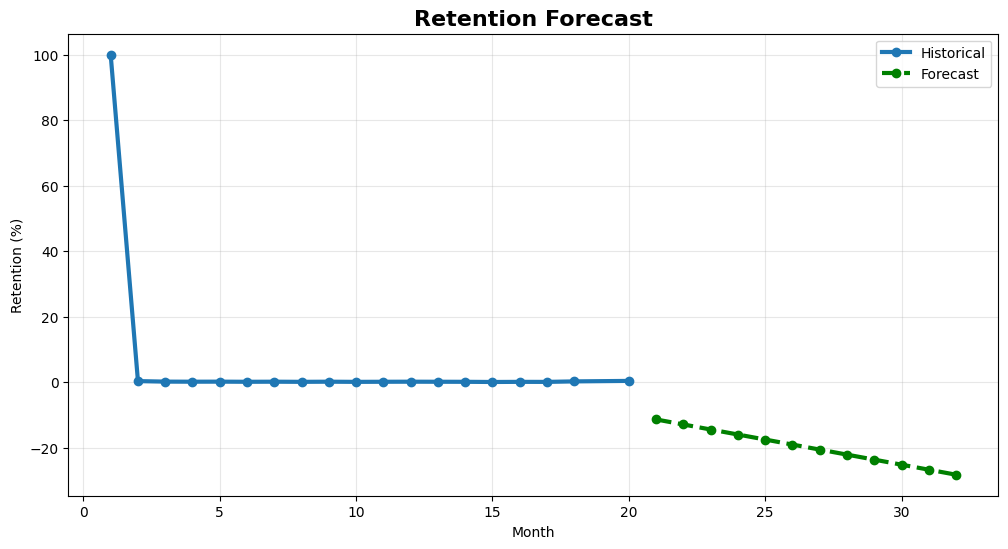

In [42]:
plt.figure(figsize=(12,6))

plt.plot(

    X.flatten(),

    y,

    marker='o',

    linewidth=3,

    label='Historical'

)

plt.plot(

    future_months,

    future_predictions,

    marker='o',

    linestyle='--',

    linewidth=3,

    color='green',

    label='Forecast'

)

plt.title(

    "Retention Forecast",

    fontsize=16,

    fontweight='bold'

)

plt.xlabel("Month")

plt.ylabel("Retention (%)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# AI Retention Advisor

In [43]:
print("="*70)

print("AI RETENTION ADVISOR")

print("="*70)

avg = average_retention.mean()

if avg > 70:
    print("Excellent customer retention.")
elif avg > 40:
    print("Retention is moderate.")
else:
    print("Retention is low and needs improvement.")

print()

print("Business Recommendations")

print("--------------------------")

if avg < 40:
    print("• Improve onboarding experience.")
    print("• Launch retention campaigns before Month 3.")
    print("• Reward repeat customers.")
    print("• Reduce customer churn through loyalty programmes.")
else:
    print("• Maintain current engagement strategy.")

AI RETENTION ADVISOR
Retention is low and needs improvement.

Business Recommendations
--------------------------
• Improve onboarding experience.
• Launch retention campaigns before Month 3.
• Reward repeat customers.
• Reduce customer churn through loyalty programmes.


# Executive KPI Dashboard

In [44]:
executive_dashboard = pd.DataFrame({

    "Metric":[

        "Total Cohorts",

        "Average Retention (%)",

        "Best Cohort",

        "Worst Cohort",

        "Average Risk Score",

        "Revenue Lost",

        "Recovery Opportunity",

        "Decay Rate"

    ],

    "Value":[

        len(retention_matrix),

        round(average_retention.mean(),2),

        best_cohort,

        worst_cohort,

        round(cohort_summary["Retention_Risk_Score"].mean(),2),

        round(cohort_summary["Estimated_Revenue_Loss"].sum(),2),

        round(cohort_summary["Recovery_Potential"].sum(),2),

        round(np.mean(np.diff(average_retention.values)),4)

    ]

})

executive_dashboard

,Metric,Value
0,Total Cohorts,25
1,Average Retention (%),5.46
2,Best Cohort,2016-09
3,Worst Cohort,2017-03
4,Average Risk Score,71.48
5,Revenue Lost,17871187.74
6,Recovery Opportunity,5361356.32
7,Decay Rate,-5.5312


# Correlation Heatmap

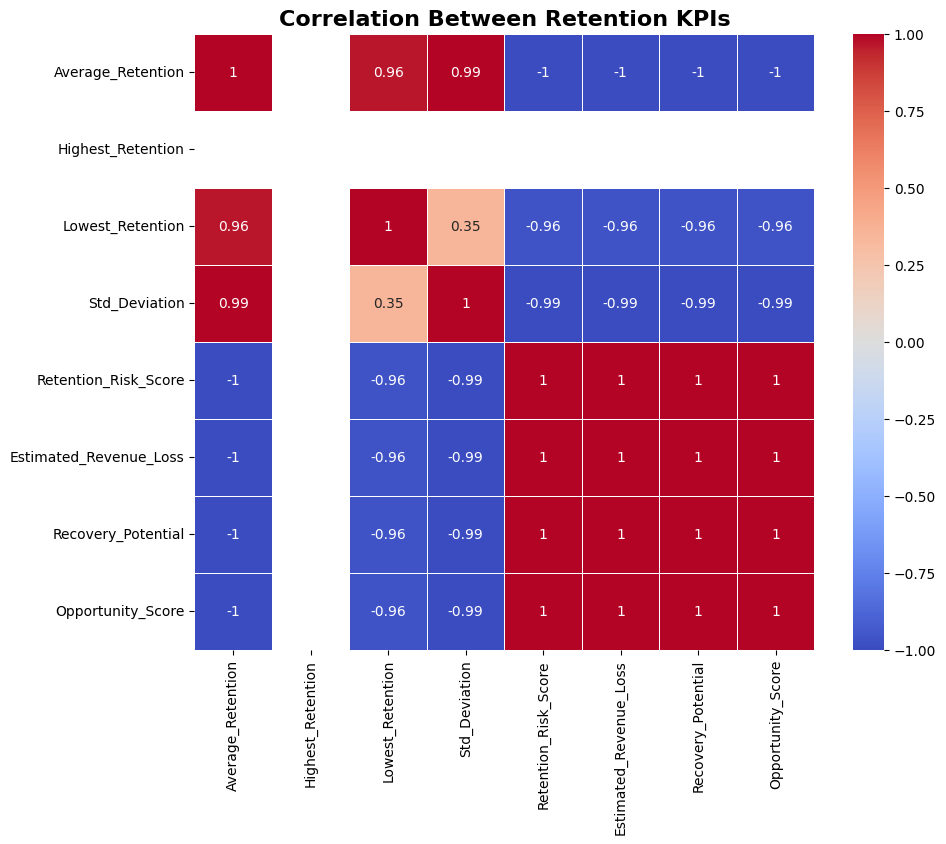

In [45]:
plt.figure(figsize=(10,8))

sns.heatmap(

    cohort_summary.corr(numeric_only=True),

    annot=True,

    cmap="coolwarm",

    linewidths=0.5

)

plt.title(

    "Correlation Between Retention KPIs",

    fontsize=16,

    fontweight="bold"

)

plt.show()

# Box Plot

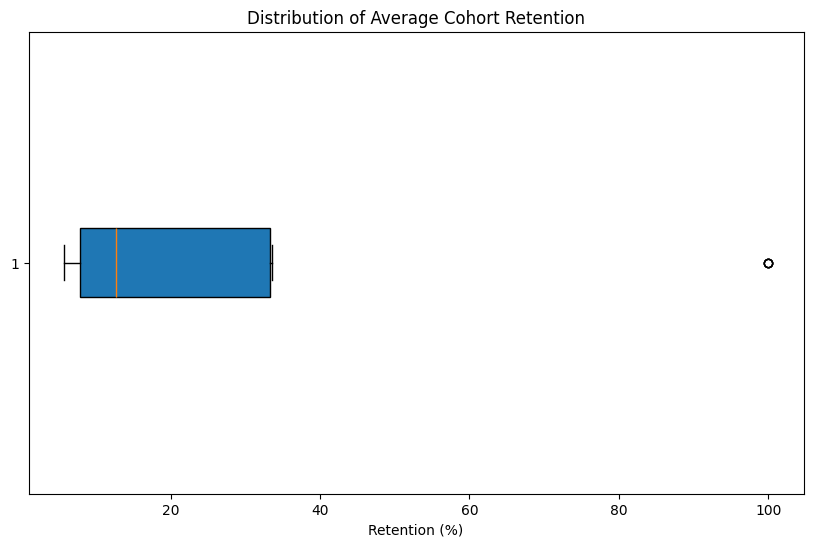

In [46]:
plt.figure(figsize=(10,6))

plt.boxplot(

    cohort_summary["Average_Retention"],

    vert=False,

    patch_artist=True

)

plt.title(

    "Distribution of Average Cohort Retention"

)

plt.xlabel("Retention (%)")

plt.show()

# Scatter Plot

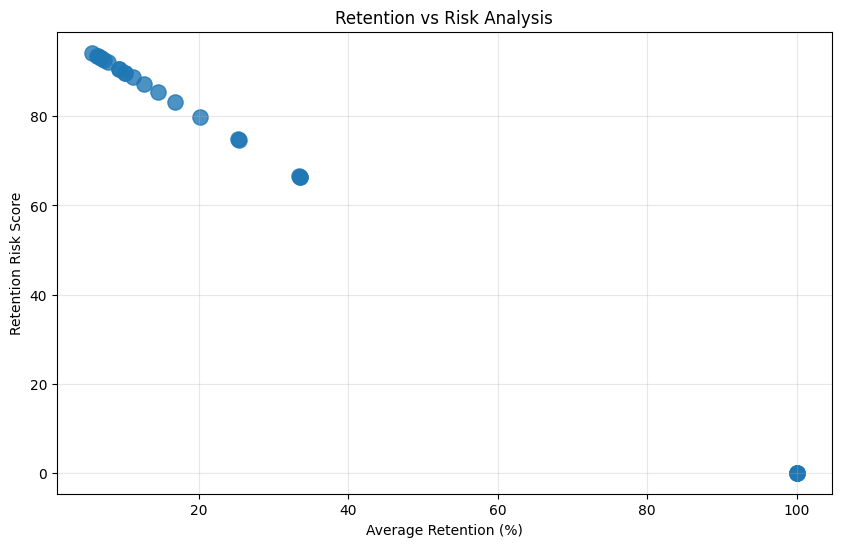

In [47]:
plt.figure(figsize=(10,6))

plt.scatter(

    cohort_summary["Average_Retention"],

    cohort_summary["Retention_Risk_Score"],

    s=120,

    alpha=0.8

)

plt.xlabel("Average Retention (%)")

plt.ylabel("Retention Risk Score")

plt.title("Retention vs Risk Analysis")

plt.grid(alpha=0.3)

plt.show()

# Bubble Chart

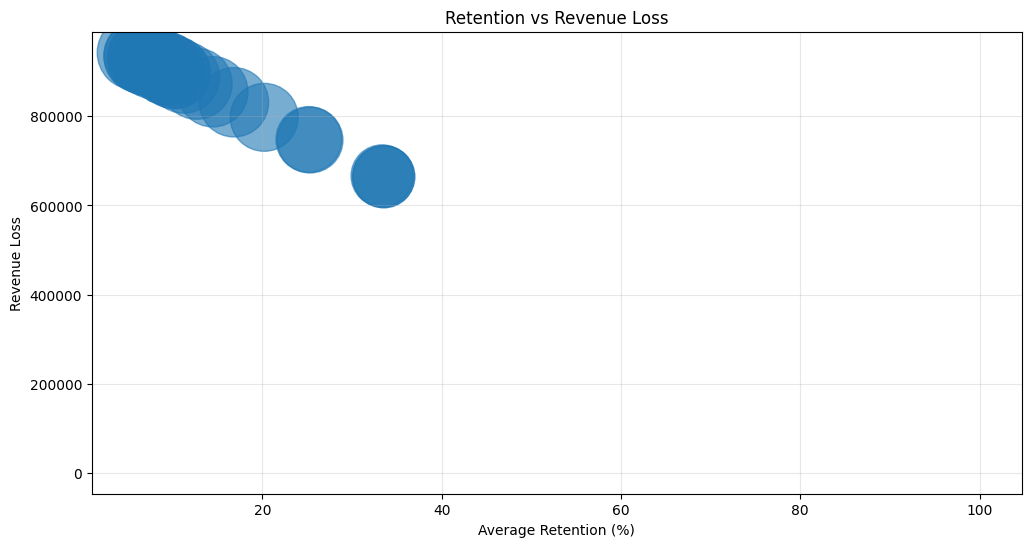

In [48]:
plt.figure(figsize=(12,6))

plt.scatter(

    cohort_summary["Average_Retention"],

    cohort_summary["Estimated_Revenue_Loss"],

    s=cohort_summary["Recovery_Potential"]/100,

    alpha=0.6

)

plt.xlabel("Average Retention (%)")

plt.ylabel("Revenue Loss")

plt.title("Retention vs Revenue Loss")

plt.grid(alpha=0.3)

plt.show()

# Executive Scorecard

In [49]:
score = 0

score += average_retention.mean()

score += (100 - cohort_summary["Retention_Risk_Score"].mean())

score = score/2

print("="*60)

print("EXECUTIVE RETENTION SCORE")

print("="*60)

print()

print(f"Overall Score : {score:.2f}/100")

if score>=80:

    print("Business Status : Excellent")

elif score>=60:

    print("Business Status : Good")

elif score>=40:

    print("Business Status : Moderate")

else:

    print("Business Status : High Risk")

EXECUTIVE RETENTION SCORE

Overall Score : 16.99/100
Business Status : High Risk


In [50]:
cohort_summary.to_csv(

    "cohort_performance_summary.csv",

    index=True

)

forecast.to_csv(

    "retention_forecast.csv",

    index=False

)

executive_dashboard.to_csv(

    "retention_dashboard.csv",

    index=False

)

customer_survival.to_csv(

    "customer_survival.csv",

    index=False

)

retention_kpi.to_csv(

    "retention_kpi.csv",

    index=False

)

print("All datasets exported successfully.")

All datasets exported successfully.


In [51]:
print("="*70)

print("COHORT RETENTION EXECUTIVE SUMMARY")

print("="*70)

print()

print(f"Number of Cohorts Analysed : {len(retention_matrix)}")

print(f"Average Retention : {average_retention.mean():.2f}%")

print(f"Best Cohort : {best_cohort}")

print(f"Worst Cohort : {worst_cohort}")

print(f"Revenue Recovery Potential : ₹{cohort_summary['Recovery_Potential'].sum():,.2f}")

print()

print("Final Recommendation")

print("-----------------------")

print("Strengthen early customer engagement, implement targeted loyalty programmes, and continuously monitor cohort performance to improve long-term customer retention and maximise customer lifetime value.")


COHORT RETENTION EXECUTIVE SUMMARY

Number of Cohorts Analysed : 25
Average Retention : 5.46%
Best Cohort : 2016-09
Worst Cohort : 2017-03
Revenue Recovery Potential : ₹5,361,356.32

Final Recommendation
-----------------------
Strengthen early customer engagement, implement targeted loyalty programmes, and continuously monitor cohort performance to improve long-term customer retention and maximise customer lifetime value.


In [52]:
print("="*70)

print("COHORT RETENTION EXECUTIVE SUMMARY")

print("="*70)

print()

print(f"Number of Cohorts Analysed : {len(retention_matrix)}")

print(f"Average Retention : {average_retention.mean():.2f}%")

print(f"Best Cohort : {best_cohort}")

print(f"Worst Cohort : {worst_cohort}")

print(f"Revenue Recovery Potential : ₹{cohort_summary['Recovery_Potential'].sum():,.2f}")

print()

print("Final Recommendation")

print("-----------------------")

print("Strengthen early customer engagement, implement targeted loyalty programmes, and continuously monitor cohort performance to improve long-term customer retention and maximise customer lifetime value.")

COHORT RETENTION EXECUTIVE SUMMARY

Number of Cohorts Analysed : 25
Average Retention : 5.46%
Best Cohort : 2016-09
Worst Cohort : 2017-03
Revenue Recovery Potential : ₹5,361,356.32

Final Recommendation
-----------------------
Strengthen early customer engagement, implement targeted loyalty programmes, and continuously monitor cohort performance to improve long-term customer retention and maximise customer lifetime value.


In [53]:
print("="*70)

print("NOTEBOOK 18 COMPLETED SUCCESSFULLY")

print("="*70)

print()

print("Modules Completed")

print("---------------------")

modules = [

    "Retention Heatmap",

    "Retention Decay Curve",

    "Cohort Performance Summary",

    "Risk Analysis",

    "Revenue Impact",

    "Customer Survival Analysis",

    "Prediction Model",

    "Forecasting",

    "AI Retention Advisor",

    "Executive Dashboard",

    "Business Intelligence",

    "Executive Reporting"

]

for i, module in enumerate(modules, start=1):

    print(f"{i}. {module}")

print()

print("Status : COMPLETE")

NOTEBOOK 18 COMPLETED SUCCESSFULLY

Modules Completed
---------------------
1. Retention Heatmap
2. Retention Decay Curve
3. Cohort Performance Summary
4. Risk Analysis
5. Revenue Impact
6. Customer Survival Analysis
7. Prediction Model
8. Forecasting
9. AI Retention Advisor
10. Executive Dashboard
11. Business Intelligence
12. Executive Reporting

Status : COMPLETE
